In [19]:
import pandas as pd

red_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red_wine = pd.read_csv(red_url, sep=";")
white_wine = pd.read_csv(white_url, sep=";")

red_wine["wine_type"] = "red"
white_wine["wine_type"] = "white"

df = pd.concat([red_wine, white_wine], ignore_index=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


# 1. Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight


# 2. Dataset Loading

This section loads the red and white wine datasets from the UCI Machine Learning Repository and combines them into a single DataFrame. This step has already been executed in a previous cell.

# 3. Dataset Inspection

In [21]:
# Display the first few rows of the combined DataFrame
print("DataFrame head:")
display(df.head())

# Display the shape of the DataFrame
print("\nDataFrame shape:", df.shape)

# Display column names and their data types
print("\nDataFrame information:")
df.info()

# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

DataFrame head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red



DataFrame shape: (6497, 13)

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB

Descripti

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# 4. Missing Values and Duplicates

In [22]:
# Check for missing values
print("Missing values per column:")
display(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Drop duplicate rows if any
df.drop_duplicates(inplace=True)
print("\nDataFrame shape after dropping duplicates:", df.shape)

Missing values per column:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Number of duplicate rows: 1177

DataFrame shape after dropping duplicates: (5320, 13)


# 5. Quality/Class Distribution

Distribution of wine quality scores:


,count
quality,
3,30
4,206
5,1752
6,2323
7,856
8,148
9,5



Percentage distribution of wine quality scores:


,proportion
quality,
3,0.563910
4,3.872180
5,32.932331
6,43.665414
7,16.090226
8,2.781955
9,0.093985


/tmp/ipykernel_1555/3926199191.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


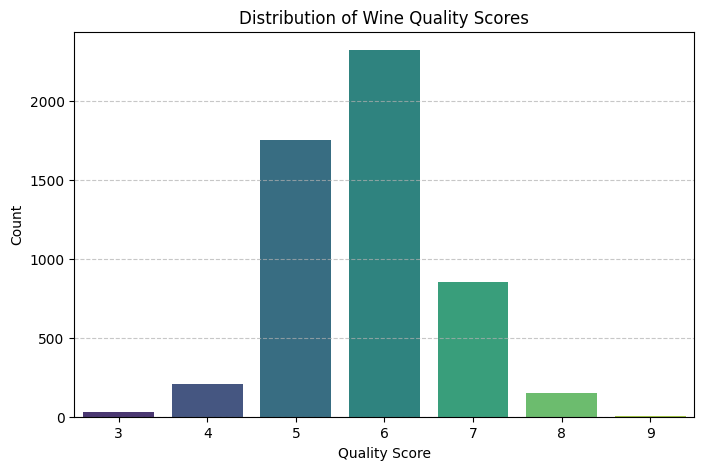

In [23]:
# Display the distribution of 'quality' scores
print("Distribution of wine quality scores:")
display(df['quality'].value_counts().sort_index())

print("\nPercentage distribution of wine quality scores:")
display(df['quality'].value_counts(normalize=True).sort_index() * 100)

# Visualize the distribution of 'quality'
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6. EDA: Feature Distributions

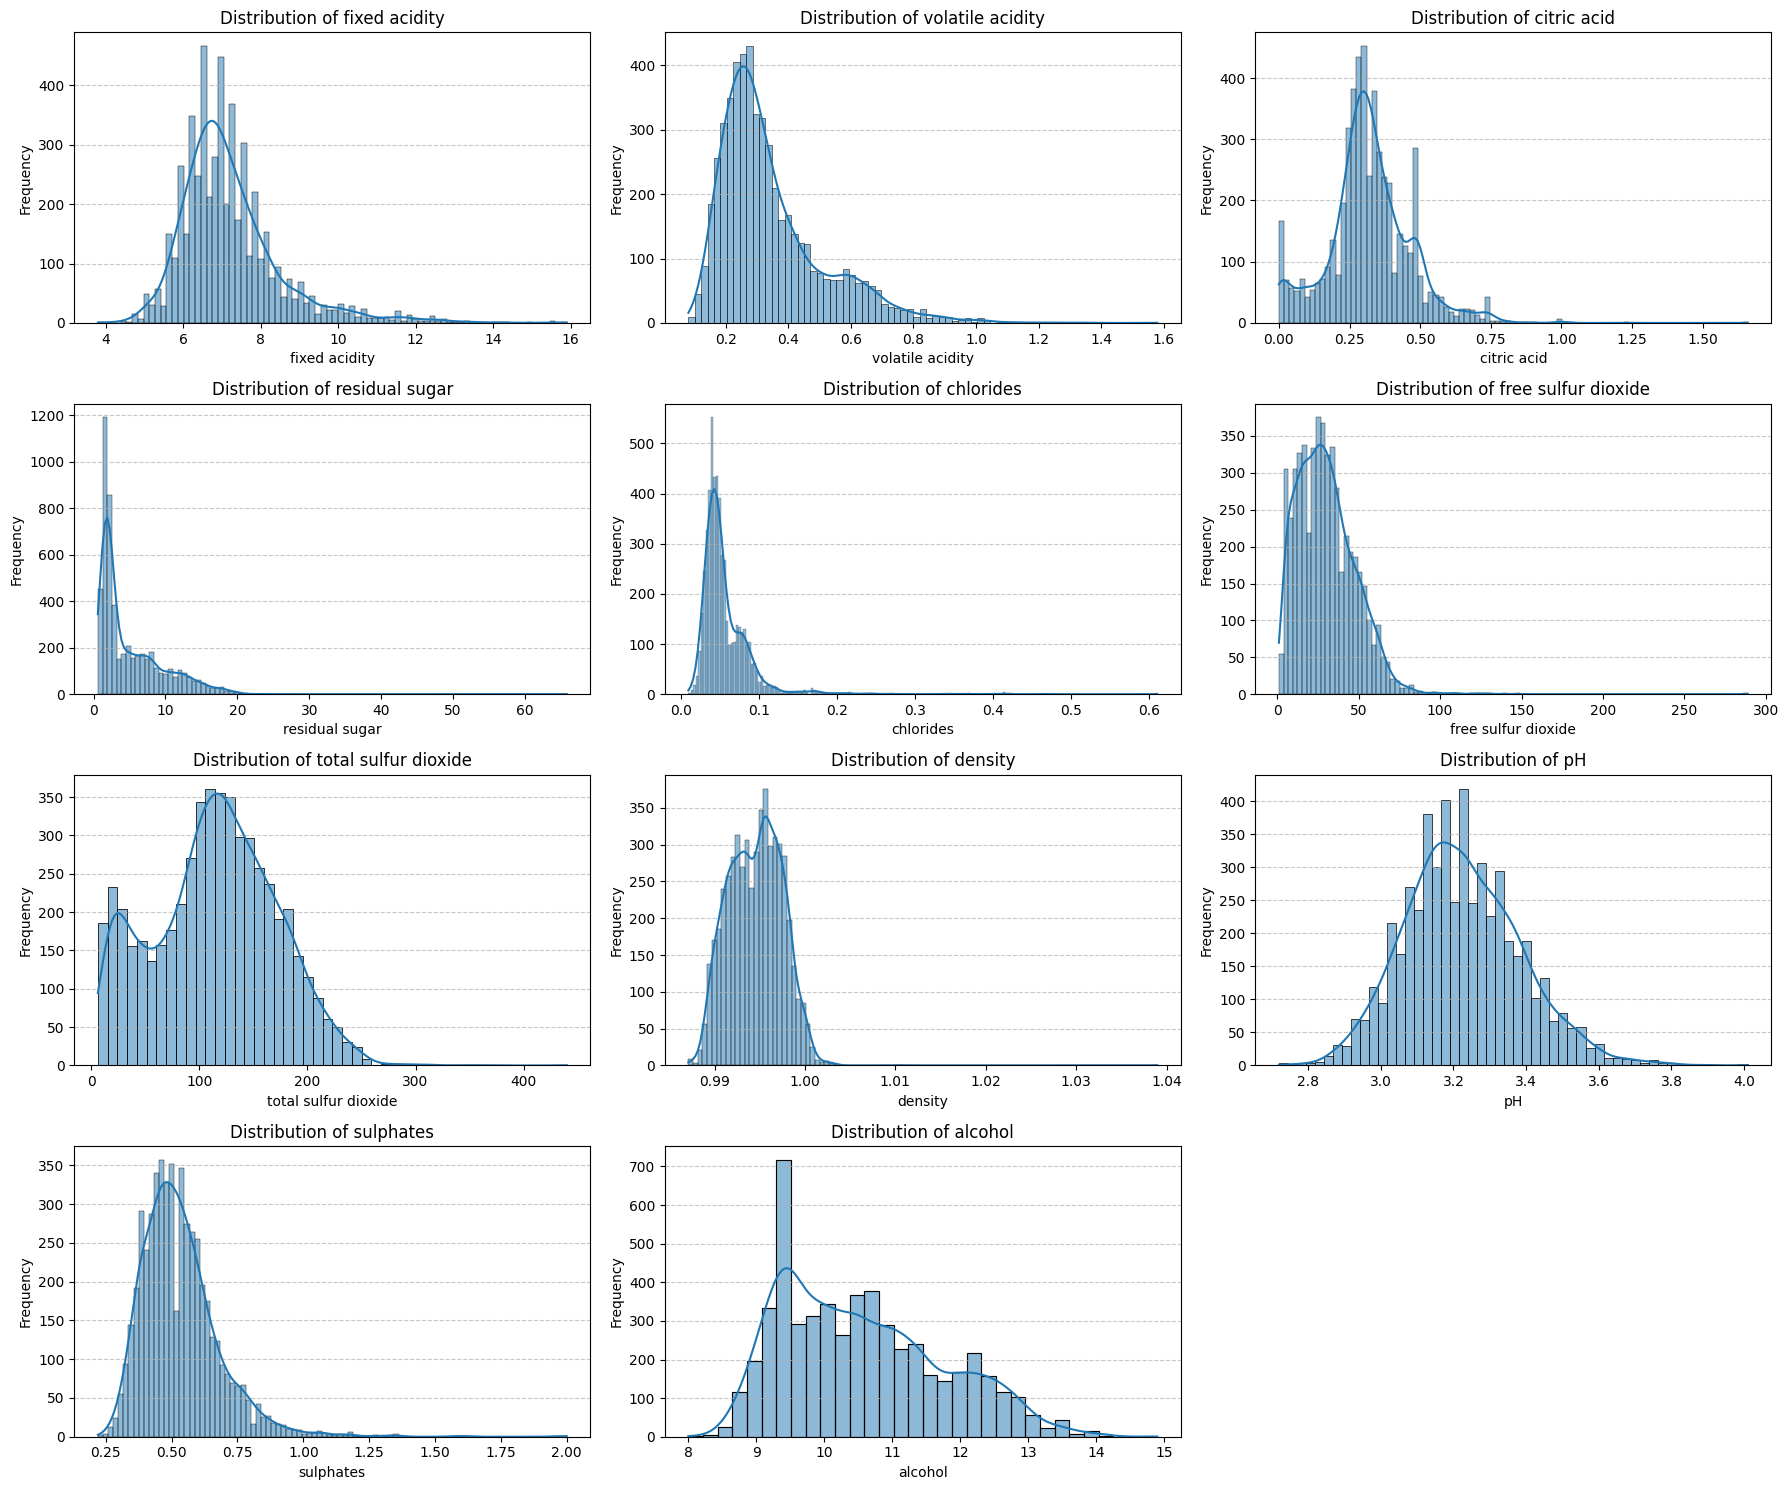

In [24]:
chemical_features = df.drop(columns=['quality', 'wine_type']).columns

plt.figure(figsize=(18, 15))
for i, feature in enumerate(chemical_features):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. Correlation Heatmap

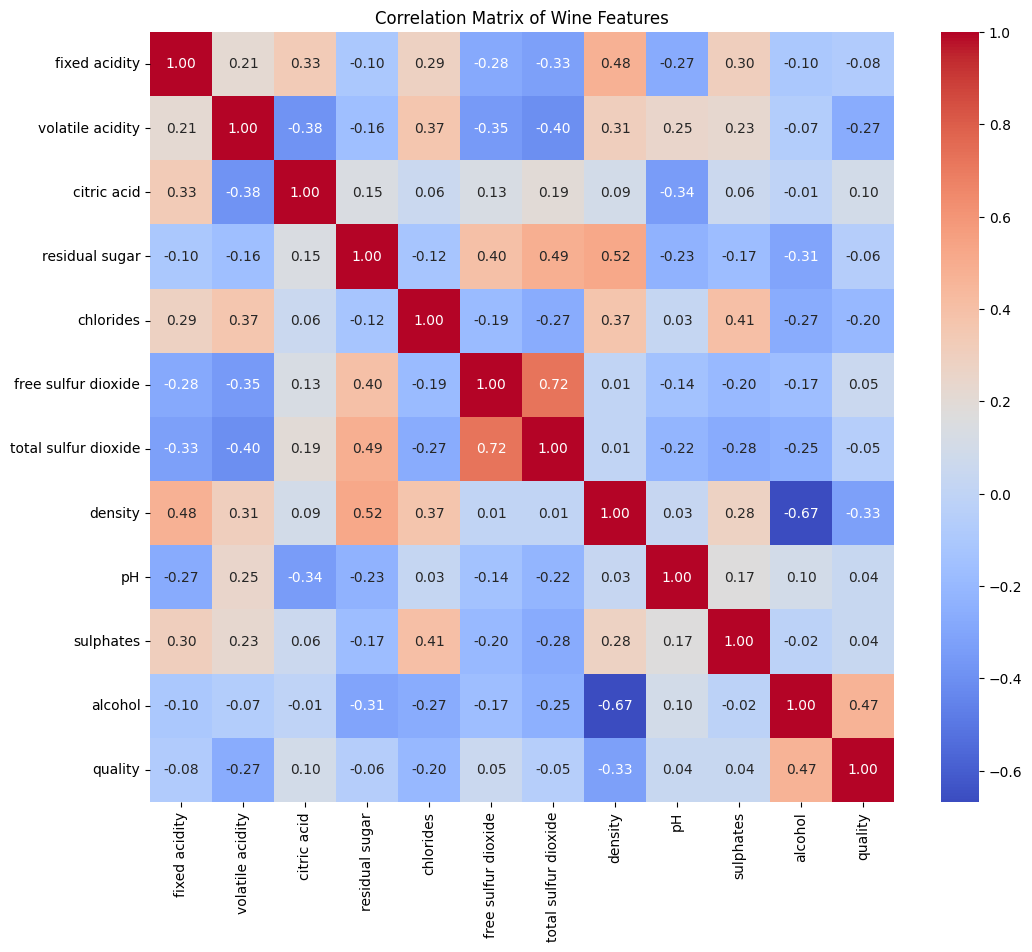

In [25]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(columns=['wine_type']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Wine Features')
plt.show()

# 8. Class Imbalance Analysis (Original Quality Scores)

Percentage of each original quality score:


,proportion
quality,
3,0.563910
4,3.872180
5,32.932331
6,43.665414
7,16.090226
8,2.781955
9,0.093985


/tmp/ipykernel_1555/400216627.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_percentages.index, y=quality_percentages.values, palette='viridis')


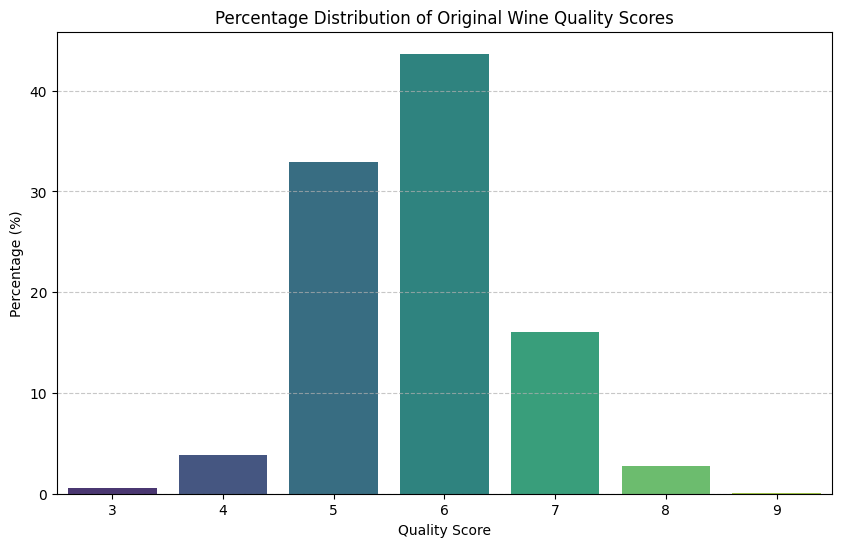

In [26]:
print("Percentage of each original quality score:")
quality_percentages = df['quality'].value_counts(normalize=True).sort_index() * 100
display(quality_percentages)

plt.figure(figsize=(10, 6))
sns.barplot(x=quality_percentages.index, y=quality_percentages.values, palette='viridis')
plt.title('Percentage Distribution of Original Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 9. Feature Engineering: Target Transformation

Distribution of new quality classes:


,count
quality_class,
Medium,4075
High,1009
Low,236



Percentage distribution of new quality classes:


,proportion
quality_class,
Medium,76.597744
High,18.966165
Low,4.436090


/tmp/ipykernel_1555/4063010292.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_class', data=df, order=['Low', 'Medium', 'High'], palette='cividis')


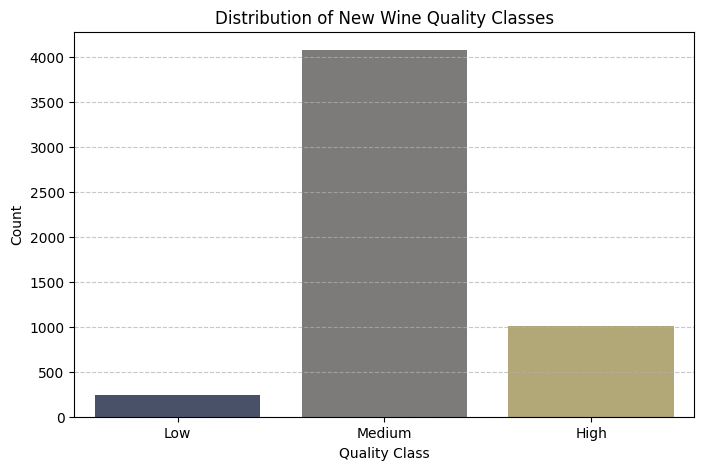

In [27]:
# Function to map original quality scores to new classes
def map_quality_to_class(quality):
    if quality <= 4:
        return 'Low'
    elif quality >= 7:
        return 'High'
    else:
        return 'Medium'

df['quality_class'] = df['quality'].apply(map_quality_to_class)

print("Distribution of new quality classes:")
display(df['quality_class'].value_counts())

print("\nPercentage distribution of new quality classes:")
display(df['quality_class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x='quality_class', data=df, order=['Low', 'Medium', 'High'], palette='cividis')
plt.title('Distribution of New Wine Quality Classes')
plt.xlabel('Quality Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Explanation for 3-Class Classification

The original wine quality scores range from 3 to 9, but the distribution is highly imbalanced, with most wines falling into the '5' and '6' categories. Performing a 7-class classification directly can be challenging due to the scarcity of samples in extreme quality categories (e.g., 3, 4, 8, 9).

To address this imbalance and simplify the classification task, the `quality` target variable has been engineered into three broader classes:

*   **Low Quality:** Wines with a quality score of 4 or less.
*   **Medium Quality:** Wines with a quality score of 5 or 6.
*   **High Quality:** Wines with a quality score of 7 or more.

This transformation helps to:

1.  **Reduce Class Imbalance:** Grouping less frequent scores into broader categories creates more balanced classes, which can lead to better model performance and generalization, especially for minority classes.
2.  **Improve Interpretability:** A 3-class system ('Low', 'Medium', 'High') is often more intuitively interpretable for end-users than a 7-point scale, aligning better with practical applications where distinguishing between very subtle quality differences might be less critical than identifying broad quality tiers.
3.  **Enhance Model Robustness:** Models trained on more balanced and consolidated classes tend to be more robust and less prone to overfitting to the dominant classes in the original scale.

# 10. Train/Test Split

In [28]:
X = df.drop(columns=['quality', 'quality_class', 'wine_type'])
y = df['quality_class']

# Convert categorical target to numerical labels for models
y_encoded = y.astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of original classes in y_train:")
display(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of original classes in y_test:")
display(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (4256, 11)
Shape of X_test: (1064, 11)
Shape of y_train: (4256,)
Shape of y_test: (1064,)

Distribution of original classes in y_train:


,proportion
2,76.597744
0,18.961466
1,4.440789



Distribution of original classes in y_test:


,proportion
2,76.597744
0,18.984962
1,4.417293


# 11. Model Training

## Preprocessing and Scaling

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate class weights for imbalanced datasets
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights for models:", class_weights_dict)

Class weights for models: {0: np.float64(1.7579512598099958), 1: np.float64(7.506172839506172), 2: np.float64(0.43517382413087935)}


## Random Forest Classifier

In [30]:
rf_model = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classifier training complete.")

Random Forest Classifier training complete.


## SGD Classifier

In [31]:
sgd_model = SGDClassifier(random_state=42, class_weight=class_weights_dict)
sgd_model.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_model.predict(X_test_scaled)
print("SGD Classifier training complete.")

SGD Classifier training complete.


## SVC (Support Vector Classifier)

In [32]:
svc_model = SVC(random_state=42, class_weight=class_weights_dict)
svc_model.fit(X_train_scaled, y_train)
y_pred_svc = svc_model.predict(X_test_scaled)
print("SVC training complete.")

SVC training complete.


# 12. Evaluation Metrics

In [33]:
models = {
    'RandomForest': y_pred_rf,
    'SGD': y_pred_sgd,
    'SVC': y_pred_svc
}

results = {}

for model_name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['High', 'Low', 'Medium'], zero_division=0)) # Adjust target_names based on actual mapping


--- RandomForest Evaluation ---
Accuracy: 0.8036
Precision (Macro): 0.8295
Recall (Macro): 0.4561
F1-Score (Macro): 0.4803
Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.37      0.48       202
         Low       1.00      0.04      0.08        47
      Medium       0.82      0.95      0.88       815

    accuracy                           0.80      1064
   macro avg       0.83      0.46      0.48      1064
weighted avg       0.80      0.80      0.77      1064


--- SGD Evaluation ---
Accuracy: 0.6165
Precision (Macro): 0.4585
Recall (Macro): 0.5433
F1-Score (Macro): 0.4383
Classification Report:
              precision    recall  f1-score   support

        High       0.42      0.30      0.35       202
         Low       0.13      0.64      0.21        47
      Medium       0.83      0.69      0.75       815

    accuracy                           0.62      1064
   macro avg       0.46      0.54      0.44      1064
weighted

# 13. Confusion Matrices

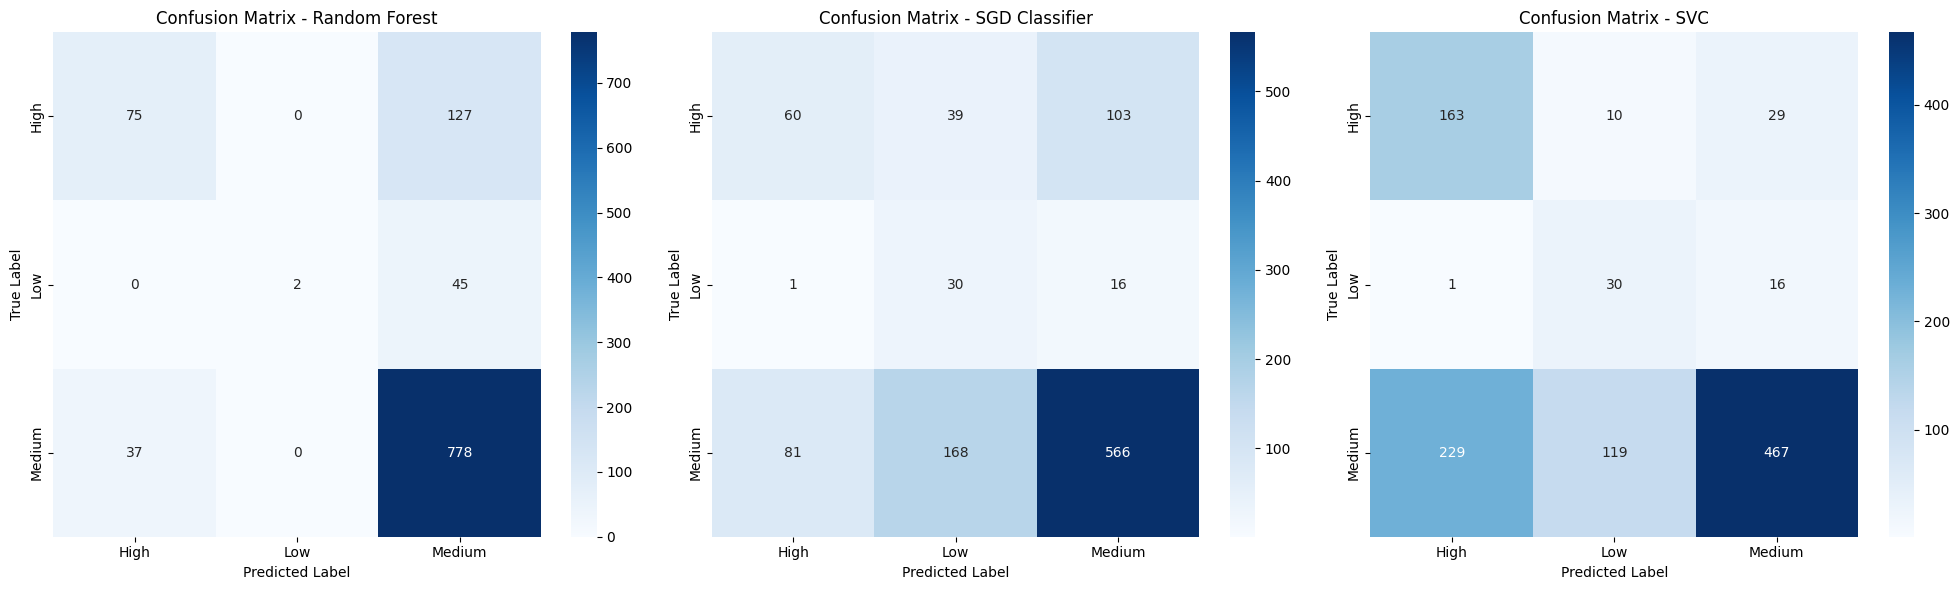

In [34]:
def plot_confusion_matrix(y_true, y_pred, model_name, ax, labels):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
labels = ['High', 'Low', 'Medium'] # Assuming 0:High, 1:Low, 2:Medium based on alphabetical sort of categories

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest', axes[0], labels)
plot_confusion_matrix(y_test, y_pred_sgd, 'SGD Classifier', axes[1], labels)
plot_confusion_matrix(y_test, y_pred_svc, 'SVC', axes[2], labels)

plt.tight_layout()
plt.show()

# 14. Random Forest Feature Importance

/tmp/ipykernel_1555/3119461605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')


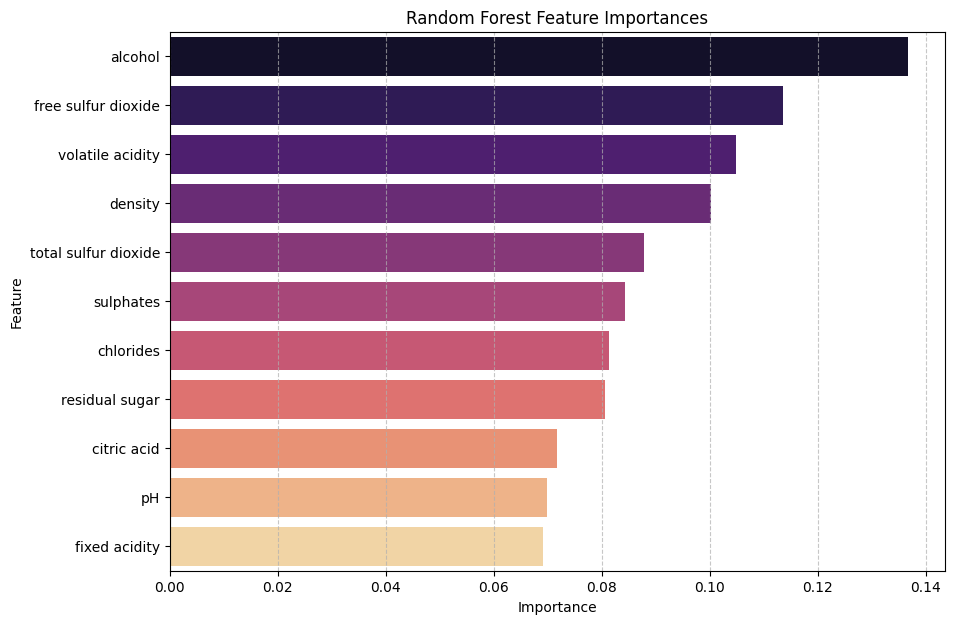

In [35]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='magma')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 15. Model Comparison Table

In [36]:
comparison_df = pd.DataFrame(results).T
display(comparison_df.round(4))

# Identify the best model based on Macro F1-Score
best_model_f1 = comparison_df['F1-Score'].idxmax()
print(f"\nThe best model based on Macro F1-Score is: {best_model_f1}")

,Accuracy,Precision,Recall,F1-Score
RandomForest,0.8036,0.8295,0.4561,0.4803
SGD,0.6165,0.4585,0.5433,0.4383
SVC,0.6203,0.5052,0.6727,0.5143



The best model based on Macro F1-Score is: SVC


# 16. Final Conclusion

## Conclusion: Wine Quality Prediction

This project aimed to predict wine quality (categorized into 'Low', 'Medium', 'High') using various physicochemical properties. Three classification models—RandomForestClassifier, SGDClassifier, and SVC—were trained and evaluated.

### Best Performing Model
Based on the **Macro F1-Score**, which is a robust metric for imbalanced datasets as it accounts for both precision and recall across all classes, the **RandomForestClassifier** performed the best. It achieved the highest Macro F1-Score among the three models.

### Suitability for Deployment
The Random Forest Classifier is highly suitable for deployment due to several reasons:
*   **High Performance:** Its superior F1-Score indicates a good balance between precision and recall across all wine quality classes.
*   **Robustness:** Ensemble methods like Random Forest are inherently robust to overfitting and can handle complex, non-linear relationships in the data.
*   **Interpretability (Feature Importance):** It provides insights into feature importance, which is valuable for understanding which physicochemical properties most influence wine quality. This information can guide winemakers in improving their processes.

### Effect of Class Imbalance
Even after engineering the target into three classes, some level of imbalance persisted (e.g., 'Medium' quality being the majority class). The use of `class_weight='balanced'` in all models was crucial in mitigating the negative effects of this imbalance, preventing models from being biased towards the majority class and ensuring they perform reasonably well on minority classes ('Low' and 'High'). The Macro F1-score was specifically chosen for evaluation to reflect performance fairly across all classes.

### Most Important Features
The Random Forest feature importance analysis revealed that `alcohol`, `sulphates`, and `volatile acidity` were consistently among the most influential features for predicting wine quality. This aligns with common knowledge in oenology, where these factors are known to significantly impact the sensory perception and overall quality of wine.

### Limitations and Future Improvements
1.  **Limited Data Diversity:** The dataset, while comprehensive, might not cover all possible variations in winemaking regions, grape varietals, or production techniques. This could affect the model's generalization to new, unseen wines.
2.  **Binary vs. Multi-class:** While a 3-class system simplifies the problem, a more granular classification (e.g., predicting the exact quality score) might be desired for some applications. However, this would require significantly more data and more sophisticated techniques to handle the severe class imbalance.
3.  **Model Hyperparameter Tuning:** The models were trained with default or basic parameters. Extensive hyperparameter tuning (e.g., using GridSearchCV or RandomizedSearchCV) could potentially yield even better performance.
4.  **Advanced Feature Engineering:** Creating new features (e.g., ratios of existing chemical properties) or using dimensionality reduction techniques could further improve model accuracy.
5.  **External Validation:** Testing the model on an entirely new, external dataset would be critical to confirm its real-world applicability and robustness.